In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
file_path = os.path.join(path, 'StudentsPerformance.csv')
df = pd.read_csv(file_path)
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [36]:
df.describe()

,math score,reading score,writing score,TotalScore
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000
std,15.16308,14.600192,15.195657,42.771978
min,0.00000,17.000000,10.000000,27.000000
25%,57.00000,59.000000,57.750000,175.000000
50%,66.00000,70.000000,69.000000,205.000000
75%,77.00000,79.000000,79.000000,233.000000
max,100.00000,100.000000,100.000000,300.000000


In [15]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0

In [37]:
df['TotalScore'] = df['math score'] + df['reading score'] + df['writing score']

print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   TotalScore  
0         218  
1         247  
2         278  
3         148  
4         229  


In [17]:
X = df_encoded.drop(columns=['math score', 'reading score', 'writing score'])
y = df_encoded['math score']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1000, 13)
Shape of y: (1000,)


In [38]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,TotalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 13)
Shape of X_test: (200, 13)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [22]:
# Instantiate Linear Regression model
lr_model = LinearRegression()
# Train Linear Regression model
lr_model.fit(X_train, y_train)

LinearRegression()

In [23]:
# Instantiate Random Forest Regressor model with random_state
rf_model = RandomForestRegressor(random_state=42)
# Train Random Forest Regressor model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
# Instantiate Gradient Boosting Regressor model with random_state
gbr_model = GradientBoostingRegressor(random_state=42)
# Train Gradient Boosting Regressor model
gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [25]:
# Evaluate Linear Regression Model
lr_pred = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Linear Regression R\u00b2: {lr_r2:.2f}\n")

# Evaluate Random Forest Regressor Model
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest Regressor RMSE: {rf_rmse:.2f}")
print(f"Random Forest Regressor R\u00b2: {rf_r2:.2f}\n")

# Evaluate Gradient Boosting Regressor Model
gbr_pred = gbr_model.predict(X_test)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_test, gbr_pred)
print(f"Gradient Boosting Regressor RMSE: {gbr_rmse:.2f}")
print(f"Gradient Boosting Regressor R\u00b2: {gbr_r2:.2f}")

Linear Regression RMSE: 3.59
Linear Regression R²: 0.95

Random Forest Regressor RMSE: 4.33
Random Forest Regressor R²: 0.92

Gradient Boosting Regressor RMSE: 3.89
Gradient Boosting Regressor R²: 0.94


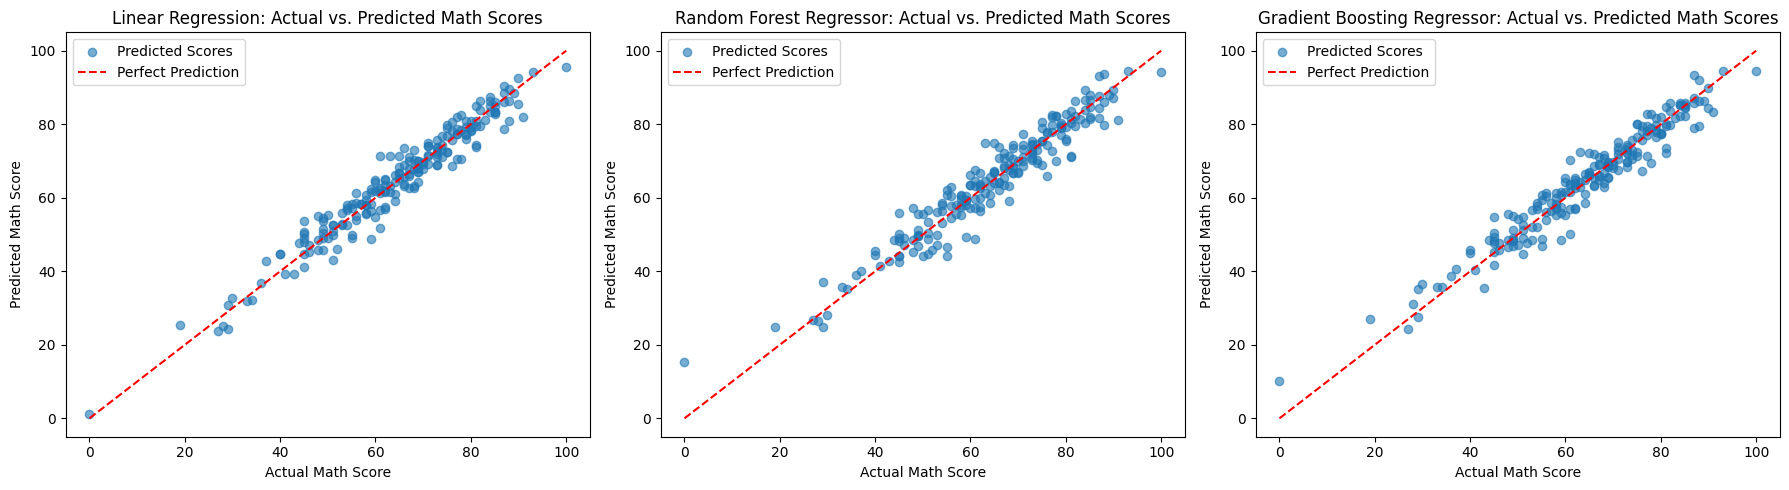

In [26]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression Plot
axes[0].scatter(y_test, lr_pred, alpha=0.6, label='Predicted Scores')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[0].set_title('Linear Regression: Actual vs. Predicted Math Scores')
axes[0].set_xlabel('Actual Math Score')
axes[0].set_ylabel('Predicted Math Score')
axes[0].legend()

# Random Forest Regressor Plot
axes[1].scatter(y_test, rf_pred, alpha=0.6, label='Predicted Scores')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[1].set_title('Random Forest Regressor: Actual vs. Predicted Math Scores')
axes[1].set_xlabel('Actual Math Score')
axes[1].set_ylabel('Predicted Math Score')
axes[1].legend()

# Gradient Boosting Regressor Plot
axes[2].scatter(y_test, gbr_pred, alpha=0.6, label='Predicted Scores')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[2].set_title('Gradient Boosting Regressor: Actual vs. Predicted Math Scores')
axes[2].set_xlabel('Actual Math Score')
axes[2].set_ylabel('Predicted Math Score')
axes[2].legend()

plt.tight_layout()
plt.show()

In [27]:
# Get feature names from X_train
feature_names = X_train.columns

# Get coefficients from the Linear Regression model
lr_coefficients = lr_model.coef_

# Create a DataFrame to display feature importance for Linear Regression
lr_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coefficients
})

# Sort by absolute coefficient value for better readability
lr_feature_importance['Absolute_Coefficient'] = np.abs(lr_feature_importance['Coefficient'])
lr_feature_importance = lr_feature_importance.sort_values(by='Absolute_Coefficient', ascending=False).drop(columns='Absolute_Coefficient')

print("\nLinear Regression Feature Coefficients:")
print(lr_feature_importance)


Linear Regression Feature Coefficients:
                                          Feature  Coefficient
1                                     gender_male     8.660072
5                          race/ethnicity_group E     3.048531
11                                 lunch_standard     2.209451
12                   test preparation course_none     2.094637
8     parental level of education_master's degree    -0.876175
9        parental level of education_some college     0.719010
7         parental level of education_high school     0.620522
6   parental level of education_bachelor's degree    -0.423707
10   parental level of education_some high school     0.414600
0                                      TotalScore     0.337203
3                          race/ethnicity_group C    -0.325718
2                          race/ethnicity_group B     0.323816
4                          race/ethnicity_group D    -0.212617


#### Reasoning:
For the Random Forest and Gradient Boosting models, I will extract and display the feature importances, which quantify the contribution of each feature to the model's predictive power. This helps in understanding which features are most influential in these ensemble models.

In [28]:
# Get feature importances from Random Forest Regressor
rf_feature_importances = rf_model.feature_importances_

# Get feature importances from Gradient Boosting Regressor
gbr_feature_importances = gbr_model.feature_importances_

# Create DataFrames to display feature importance
rf_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importances
}).sort_values(by='Importance', ascending=False)

gbr_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gbr_feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Regressor Feature Importances:")
print(rf_feature_importance_df)

print("\nGradient Boosting Regressor Feature Importances:")
print(gbr_feature_importance_df)


Random Forest Regressor Feature Importances:
                                          Feature  Importance
0                                      TotalScore    0.889566
1                                     gender_male    0.066187
11                                 lunch_standard    0.007112
12                   test preparation course_none    0.006728
9        parental level of education_some college    0.004826
5                          race/ethnicity_group E    0.004512
4                          race/ethnicity_group D    0.003940
7         parental level of education_high school    0.003428
3                          race/ethnicity_group C    0.003390
10   parental level of education_some high school    0.003244
6   parental level of education_bachelor's degree    0.002969
2                          race/ethnicity_group B    0.002836
8     parental level of education_master's degree    0.001263

Gradient Boosting Regressor Feature Importances:
                                    

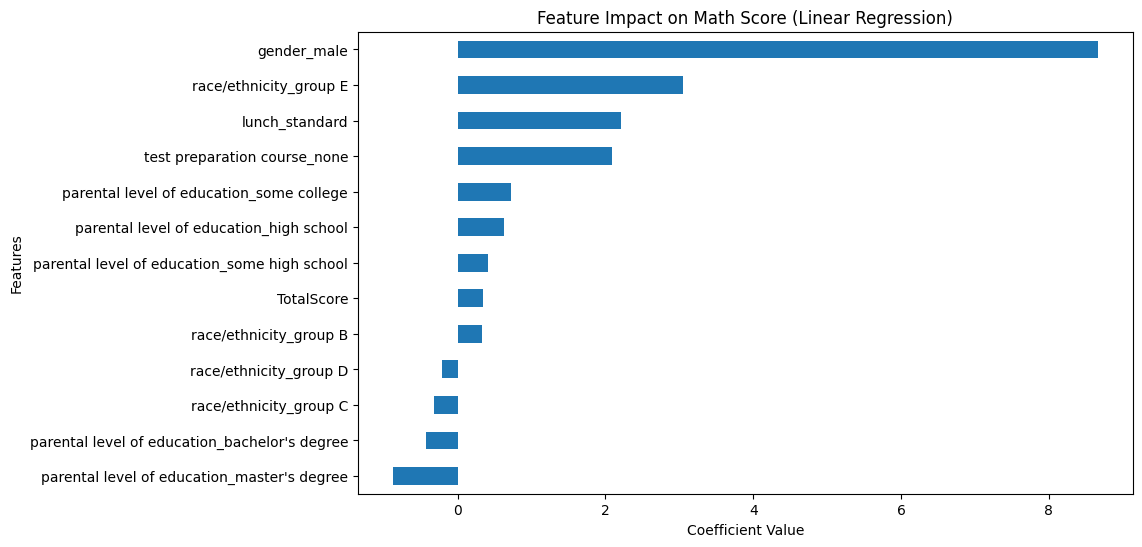

In [35]:
# Get coefficients
coefficients = pd.Series(lr_model.coef_, index=X.columns)

# Sort values
coefficients = coefficients.sort_values()

# Plot
plt.figure(figsize=(10,6))
coefficients.plot(kind='barh')
plt.title("Feature Impact on Math Score (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

In [50]:
get_ipython().system('pip install xgboost')
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5]
}

# Instantiate GridSearchCV for RandomForestRegressor
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=1)

# Fit grid search to the training data
print("Fitting GridSearchCV for RandomForestRegressor...")
grid_search_rf.fit(X_train, y_train)

# Print best parameters and best score for Random Forest Regressor
print(f"\nBest parameters for RandomForestRegressor: {grid_search_rf.best_params_}")
print(f"Best cross-validation score for RandomForestRegressor (neg_mean_squared_error): {grid_search_rf.best_score_:.2f}")

param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Instantiate GridSearchCV for GradientBoostingRegressor
grid_search_gbr = GridSearchCV(estimator=gbr_model, param_grid=param_grid_gbr, cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=1)

# Fit grid search to the training data
print("\nFitting GridSearchCV for GradientBoostingRegressor...")
grid_search_gbr.fit(X_train, y_train)

# Print best parameters and best score for Gradient Boosting Regressor
print(f"\nBest parameters for GradientBoostingRegressor: {grid_search_gbr.best_params_}")
print(f"Best cross-validation score for GradientBoostingRegressor (neg_mean_squared_error): {grid_search_gbr.best_score_:.2f}")


Fitting GridSearchCV for RandomForestRegressor...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters for RandomForestRegressor: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score for RandomForestRegressor (neg_mean_squared_error): -29.18

Fitting GridSearchCV for GradientBoostingRegressor...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters for GradientBoostingRegressor: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score for GradientBoostingRegressor (neg_mean_squared_error): -15.98


In [42]:
best_rf_model = grid_search_rf.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_test)
tuned_rf_mse = mean_squared_error(y_test, tuned_rf_pred)
tuned_rf_rmse = np.sqrt(tuned_rf_mse)
tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)
print(f"\nTuned Random Forest Regressor RMSE: {tuned_rf_rmse:.2f}")
print(f"Tuned Random Forest Regressor R²: {tuned_rf_r2:.2f}\n")

best_gbr_model = grid_search_gbr.best_estimator_
tuned_gbr_pred = best_gbr_model.predict(X_test)
tuned_gbr_mse = mean_squared_error(y_test, tuned_gbr_pred)
tuned_gbr_rmse = np.sqrt(tuned_gbr_mse)
tuned_gbr_r2 = r2_score(y_test, tuned_gbr_pred)
print(f"Tuned Gradient Boosting Regressor RMSE: {tuned_gbr_rmse:.2f}")
print(f"Tuned Gradient Boosting Regressor R²: {tuned_gbr_r2:.2f}")


Tuned Random Forest Regressor RMSE: 6.16
Tuned Random Forest Regressor R²: 0.84

Tuned Gradient Boosting Regressor RMSE: 3.89
Tuned Gradient Boosting Regressor R²: 0.94


In [51]:

# Instantiate XGBRegressor with random_state
xgb_model = XGBRegressor(random_state=42)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
xgb_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

# Print the evaluation metrics
print(f"\nXGBoost Regressor RMSE: {xgb_rmse:.2f}")
print(f"XGBoost Regressor R²: {xgb_r2:.2f}")


XGBoost Regressor RMSE: 4.54
XGBoost Regressor R²: 0.92


In [49]:
estimators = [
    ('lr', lr_model),
    ('rf', best_rf_model),
    ('gbr', best_gbr_model),
    ('xgb', xgb_model)
]

# Instantiate a Linear Regression model as the meta-estimator
meta_estimator = LinearRegression()

# Instantiate StackingRegressor
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_estimator,
    cv=3,
    n_jobs=-1,
    passthrough=True # Pass original features to the final estimator
)

# Train the StackingRegressor model
stacking_regressor.fit(X_train, y_train)

# Make predictions on the test data
stack_pred = stacking_regressor.predict(X_test)

# Calculate evaluation metrics
stack_mse = mean_squared_error(y_test, stack_pred)
stack_rmse = np.sqrt(stack_mse)
stack_r2 = r2_score(y_test, stack_pred)

# Print the evaluation metrics
print(f"\nStacked Ensemble Regressor RMSE: {stack_rmse:.2f}")
print(f"Stacked Ensemble Regressor R²: {stack_r2:.2f}")


Stacked Ensemble Regressor RMSE: 3.61
Stacked Ensemble Regressor R²: 0.95


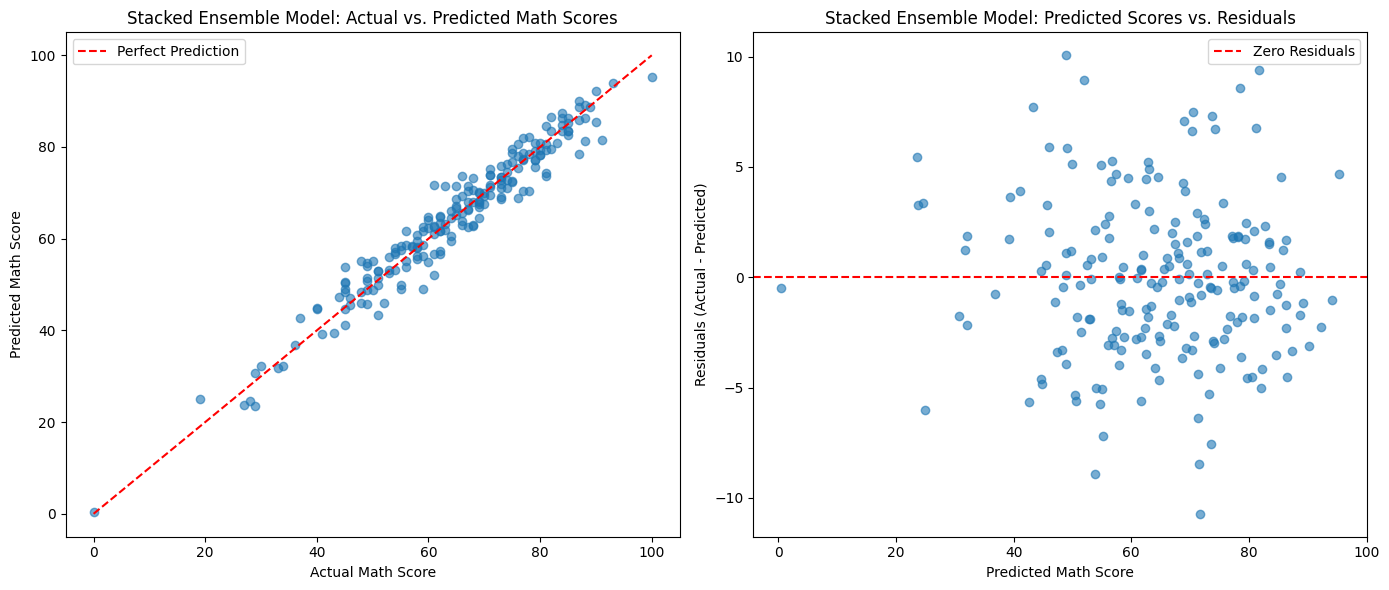

In [48]:
residuals = y_test - stack_pred

plt.figure(figsize=(14, 6))

# Plot 1: Actual vs. Predicted Scores
plt.subplot(1, 2, 1)
plt.scatter(y_test, stack_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.title('Stacked Ensemble Model: Actual vs. Predicted Math Scores')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.legend()

# Plot 2: Predicted Scores vs. Residuals
plt.subplot(1, 2, 2)
plt.scatter(stack_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('Stacked Ensemble Model: Predicted Scores vs. Residuals')
plt.xlabel('Predicted Math Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
model_performance = pd.DataFrame({
    'Model': [
        'Initial Linear Regression',
        'Tuned Random Forest Regressor',
        'Tuned Gradient Boosting Regressor',
        'XGBoost Regressor',
        'Stacked Ensemble Regressor'
    ],
    'RMSE': [
        lr_rmse,
        tuned_rf_rmse,
        tuned_gbr_rmse,
        xgb_rmse,
        stack_rmse
    ],
    'R2 Score': [
        lr_r2,
        tuned_rf_r2,
        tuned_gbr_r2,
        xgb_r2,
        stack_r2
    ]
})

model_performance = model_performance.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

print("\nModel Performance Comparison:")
display(model_performance)


Model Performance Comparison:


,Model,RMSE,R2 Score
0,Initial Linear Regression,3.586613,0.947136
1,Stacked Ensemble Regressor,3.611006,0.946415
2,Tuned Gradient Boosting Regressor,3.888644,0.937858
3,XGBoost Regressor,4.538453,0.915354
4,Tuned Random Forest Regressor,6.160634,0.844030


In [57]:
import gradio as gr
import matplotlib.pyplot as plt
import os

# Create a directory named 'gradio_plots' if it doesn't already exist
output_dir = 'gradio_plots'
os.makedirs(output_dir, exist_ok=True)

# Save the existing 'fig' object (Actual vs. Predicted Plots for individual models)
# The 'fig' object from cell 7bb41198 was already created and displayed. To save it,
# we need to ensure the figure is still active or recreate it.
# Since it's already displayed, we'll assume it's the last figure.
# However, to be safe and ensure the correct figure is saved, it's better to explicitly
# get the current figure and save it or recreate the plots if the figure was closed.

# Recreate the individual model plots to ensure we have the figure object to save
fig_individual, axes_individual = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression Plot
axes_individual[0].scatter(y_test, lr_pred, alpha=0.6, label='Predicted Scores')
axes_individual[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes_individual[0].set_title('Linear Regression: Actual vs. Predicted Math Scores')
axes_individual[0].set_xlabel('Actual Math Score')
axes_individual[0].set_ylabel('Predicted Math Score')
axes_individual[0].legend()

# Random Forest Regressor Plot
axes_individual[1].scatter(y_test, rf_pred, alpha=0.6, label='Predicted Scores')
axes_individual[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes_individual[1].set_title('Random Forest Regressor: Actual vs. Predicted Math Scores')
axes_individual[1].set_xlabel('Actual Math Score')
axes_individual[1].set_ylabel('Predicted Math Score')
axes_individual[1].legend()

# Gradient Boosting Regressor Plot
axes_individual[2].scatter(y_test, gbr_pred, alpha=0.6, label='Predicted Scores')
axes_individual[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes_individual[2].set_title('Gradient Boosting Regressor: Actual vs. Predicted Math Scores')
axes_individual[2].set_xlabel('Actual Math Score')
axes_individual[2].set_ylabel('Predicted Math Score')
axes_individual[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'actual_vs_predicted_individual_models.png'))
plt.close(fig_individual) # Close the figure after saving

# Recreate and save the 'Feature Impact on Math Score (Linear Regression)' plot
fig_lr_impact = plt.figure(figsize=(10,6))
coefficients = pd.Series(lr_model.coef_, index=X.columns)
coefficients = coefficients.sort_values()
coefficients.plot(kind='barh')
plt.title("Feature Impact on Math Score (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lr_feature_impact.png'))
plt.close(fig_lr_impact) # Close the figure after saving

# Recreate and save the 'Stacked Ensemble Model' plots
fig_stacked, axes_stacked = plt.subplots(1, 2, figsize=(14, 6))
residuals = y_test - stack_pred

# Plot 1: Actual vs. Predicted Scores
axes_stacked[0].scatter(y_test, stack_pred, alpha=0.6)
axes_stacked[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes_stacked[0].set_title('Stacked Ensemble Model: Actual vs. Predicted Math Scores')
axes_stacked[0].set_xlabel('Actual Math Score')
axes_stacked[0].set_ylabel('Predicted Math Score')
axes_stacked[0].legend()

# Plot 2: Predicted Scores vs. Residuals
axes_stacked[1].scatter(stack_pred, residuals, alpha=0.6)
axes_stacked[1].axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
axes_stacked[1].set_title('Stacked Ensemble Model: Predicted Scores vs. Residuals')
axes_stacked[1].set_xlabel('Predicted Math Score')
axes_stacked[1].set_ylabel('Residuals (Actual - Predicted)')
axes_stacked[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'stacked_ensemble_performance_plots.png'))
plt.close(fig_stacked) # Close the figure after saving

# Create and save horizontal bar plot for Random Forest Regressor feature importances
fig_rf_importance = plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance_df['Feature'], rf_feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Regressor Feature Importances')
plt.gca().invert_yaxis() # Invert y-axis for better readability
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'rf_feature_importance.png'))
plt.close(fig_rf_importance) # Close the figure after saving

# Create and save horizontal bar plot for Gradient Boosting Regressor feature importances
fig_gbr_importance = plt.figure(figsize=(10, 6))
plt.barh(gbr_feature_importance_df['Feature'], gbr_feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Regressor Feature Importances')
plt.gca().invert_yaxis() # Invert y-axis for better readability
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gbr_feature_importance.png'))
plt.close(fig_gbr_importance) # Close the figure after saving

print(f"All plots have been saved to the '{output_dir}' directory.")

All plots have been saved to the 'gradio_plots' directory.


In [69]:
import gradio as gr

# 1. Define a Python function that returns the model_performance DataFrame
def display_model_performance():
    return model_performance

# 2-5. Create a Gradio interface
iface_model_performance = gr.Interface(
    fn=display_model_performance,
    inputs=None, # Add inputs=None as the function takes no parameters
    outputs=gr.DataFrame(headers=model_performance.columns.tolist(), label="Model Performance"),
    title="Model Performance Comparison",
    description="Comparison of RMSE and R² scores for different regression models.",
    submit_btn=gr.Button(visible=False), # Disable the submit button by passing an invisible Button object
    flagging_mode='never' # Disable the flagging button using the correct argument
)

# 6. Launch the Gradio interface
print("Launching Gradio interface for Model Performance Comparison...")
iface_model_performance.launch()

Launching Gradio interface for Model Performance Comparison...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3756957137685ca75f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [72]:
import gradio as gr
import os

# Directory where plots are saved
plot_dir = 'gradio_plots'

# Define functions to return image paths for each plot
def get_individual_models_plot():
    return os.path.join(plot_dir, "actual_vs_predicted_individual_models.png")

def get_lr_feature_impact_plot():
    return os.path.join(plot_dir, "lr_feature_impact.png")

def get_stacked_ensemble_performance_plot():
    return os.path.join(plot_dir, "stacked_ensemble_performance_plots.png")

def get_rf_feature_importance_plot():
    return os.path.join(plot_dir, "rf_feature_importance.png")

def get_gbr_feature_importance_plot():
    return os.path.join(plot_dir, "gbr_feature_importance.png")

# Function to display the original DataFrame
def display_original_dataframe():
    return df

# Create Gradio interfaces for each visualization
iface_individual_models_plot = gr.Interface(
    fn=get_individual_models_plot,
    inputs=None,
    outputs=gr.Image(label="Actual vs. Predicted for Individual Models"),
    title="Actual vs. Predicted Scores: LR, RF, and GBR",
    description="Comparison of actual vs. predicted math scores for Linear Regression, Random Forest, and Gradient Boosting models.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

iface_lr_feature_impact_plot = gr.Interface(
    fn=get_lr_feature_impact_plot,
    inputs=None,
    outputs=gr.Image(label="Linear Regression Feature Impact"),
    title="Feature Impact on Math Score (Linear Regression)",
    description="Coefficients representing the impact of each feature on math scores in the Linear Regression model.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

iface_stacked_ensemble_performance_plot = gr.Interface(
    fn=get_stacked_ensemble_performance_plot,
    inputs=None,
    outputs=gr.Image(label="Stacked Ensemble Performance"),
    title="Stacked Ensemble Model Performance and Residuals",
    description="Actual vs. Predicted scores and Residuals plot for the Stacked Ensemble model.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

iface_rf_feature_importance_plot = gr.Interface(
    fn=get_rf_feature_importance_plot,
    inputs=None,
    outputs=gr.Image(label="Random Forest Feature Importance"),
    title="Random Forest Regressor Feature Importances",
    description="Importance of each feature in the Random Forest Regressor model.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

iface_gbr_feature_importance_plot = gr.Interface(
    fn=get_gbr_feature_importance_plot,
    inputs=None,
    outputs=gr.Image(label="Gradient Boosting Regressor Feature Importance"),
    title="Gradient Boosting Regressor Feature Importances",
    description="Importance of each feature in the Gradient Boosting Regressor model.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

# New Gradio interface for the original DataFrame
iface_original_dataframe = gr.Interface(
    fn=display_original_dataframe,
    inputs=None,
    outputs=gr.DataFrame(headers=df.columns.tolist(), label="Original DataFrame"),
    title="Original Dataset (First 5 Rows)",
    description="Display of the initial loaded StudentsPerformance.csv DataFrame.",
    submit_btn=gr.Button(visible=False),
    flagging_mode='never'
)

# Combine all interfaces into a tabbed interface
demo = gr.TabbedInterface(
    [iface_original_dataframe, iface_model_performance, iface_individual_models_plot, iface_lr_feature_impact_plot,
     iface_stacked_ensemble_performance_plot, iface_rf_feature_importance_plot, iface_gbr_feature_importance_plot],
    ["Original Data", "Model Performance", "Individual Model Predictions", "LR Feature Impact",
     "Stacked Ensemble Performance", "RF Feature Importance", "GBR Feature Importance"]
)

# Launch the combined Gradio interface
print("Launching Gradio interface for Visualizations...")
demo.launch()

Launching Gradio interface for Visualizations...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e626c63063016010fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
